In [69]:
#import libraries
import pandas as pd
import glob
from datetime import datetime
from io import StringIO
import boto3
import s3fs
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

In [70]:
#S3 path details
bucket_name = 'csis4495'
folder_name = 'weekly_artificial_plants'
file_pattern = 'weekly_products_artificial_plants_'

# Initialize s3fs filesystem object
fs = s3fs.S3FileSystem(anon=False)  # Use anon=False if your S3 bucket is private

# List all files in the specified folder
path = f'{bucket_name}/{folder_name}'  # Adjusted to include the folder name
files = fs.ls(path)

# Filter files by your pattern
csv_files = [f for f in files if file_pattern in f]

# Read and concatenate all matching CSV files into a single DataFrame
df_list = []
for file in csv_files:
    with fs.open(f'{file}') as f:
        df_list.append(pd.read_csv(f, encoding='ISO-8859-1'))

df = pd.concat(df_list, ignore_index=True)


# Add a new column with 'artificial' as its value for every row
df['product_type'] = 'artificial'

# Summing stock numbers for British Columbia (BC)
df['stock_number_BC'] = df['stock_number_coquitlam'] + df['stock_number_richmond']

# Summing stock numbers for Quebec (QC)
df['stock_number_QC'] = df['stock_number_quebec'] + df['stock_number_boucherville'] + df['stock_number_montreal']

# Stock number for Nova Scotia (NS) is just from Halifax
df['stock_number_NS'] = df['stock_number_halifax']

# Summing stock numbers for Ontario (ON)
df['stock_number_ON'] = df['stock_number_ottawa'] + df['stock_number_nyork'] + df['stock_number_etobicoke'] + df['stock_number_vaughan'] + df['stock_number_burlington']

# Stock number for Manitoba (MB) is just from Winnipeg
df['stock_number_MB'] = df['stock_number_winnipeg']

# Summing stock numbers for Alberta (AB)
df['stock_number_AB'] = df['stock_number_edmonton'] + df['stock_number_calgary']

# Display the shape and first few rows of the concatenated DataFrame
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2593 entries, 0 to 2592
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   current_date                    2593 non-null   object
 1   image_url                       2593 non-null   object
 2   product_name                    2593 non-null   object
 3   product_link                    2593 non-null   object
 4   product_size                    2470 non-null   object
 5   product_sku                     2593 non-null   int64 
 6   product_price_old               2593 non-null   object
 7   product_price_new               56 non-null     object
 8   stock_probability_coquitlam     2593 non-null   object
 9   stock_number_coquitlam          2593 non-null   int64 
 10  stock_probability_richmond      2593 non-null   object
 11  stock_number_richmond           2593 non-null   int64 
 12  stock_probability_halifax       2593 non-null   

In [71]:
# # Initialize s3fs filesystem object
# fs = s3fs.S3FileSystem(anon=False)

# # Function to read and concatenate files from a specific folder with a specific pattern
# def read_and_label(folder_name, file_pattern, label):
#     path = f'csis4495/{folder_name}'  # Adjusted to include the folder name
#     files = fs.ls(path)
#     csv_files = [f for f in files if file_pattern in f]
#     df_list = []
#     for file in csv_files:
#         with fs.open(f'{file}') as f:
#             df_temp = pd.read_csv(f, encoding='ISO-8859-1')
#             df_temp['product_type'] = label  # Add type label while reading each file
#             df_list.append(df_temp)
#     return pd.concat(df_list, ignore_index=True)

# # Read and label artificial plants
# df_artificial = read_and_label('weekly_artificial_plants', 'weekly_products_artificial_plants_', 'artificial')

# # Read and label real plants
# df_real = read_and_label('weekly_real_plants', 'weekly_products_real_plants_', 'real')

# # Concatenate both DataFrames
# df = pd.concat([df_artificial, df_real], ignore_index=True)

# # Display the shape and first few rows of the concatenated DataFrame
# print(df.shape)
# print(df.head())

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2593 entries, 0 to 2592
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   current_date                    2593 non-null   object
 1   image_url                       2593 non-null   object
 2   product_name                    2593 non-null   object
 3   product_link                    2593 non-null   object
 4   product_size                    2470 non-null   object
 5   product_sku                     2593 non-null   int64 
 6   product_price_old               2593 non-null   object
 7   product_price_new               56 non-null     object
 8   stock_probability_coquitlam     2593 non-null   object
 9   stock_number_coquitlam          2593 non-null   int64 
 10  stock_probability_richmond      2593 non-null   object
 11  stock_number_richmond           2593 non-null   int64 
 12  stock_probability_halifax       2593 non-null   

In [73]:
print(df.shape)
print(df.head())

(2593, 43)
  current_date                                          image_url  \
0   2024-02-05  https://www.ikea.com/ca/en/images/products/fej...   
1   2024-02-05  https://www.ikea.com/ca/en/images/products/fej...   
2   2024-02-05  https://www.ikea.com/ca/en/images/products/fej...   
3   2024-02-05  https://www.ikea.com/ca/en/images/products/fej...   
4   2024-02-05  https://www.ikea.com/ca/en/images/products/fej...   

                               product_name  \
0            FEJKA, Artificial potted plant   
1  FEJKA, Artificial plant with wall holder   
2            FEJKA, Artificial potted plant   
3            FEJKA, Artificial potted plant   
4            FEJKA, Artificial potted plant   

                                        product_link   product_size  \
0  https://www.ikea.com/ca/en/p/fejka-artificial-...    23 cm (9 ")   
1  https://www.ikea.com/ca/en/p/fejka-artificial-...            NaN   
2  https://www.ikea.com/ca/en/p/fejka-artificial-...  21 cm (8 ¼ ")   
3  http

## Data Cleaning

In [74]:
df.isnull().sum()

current_date                         0
image_url                            0
product_name                         0
product_link                         0
product_size                       123
product_sku                          0
product_price_old                    0
product_price_new                 2537
stock_probability_coquitlam          0
stock_number_coquitlam               0
stock_probability_richmond           0
stock_number_richmond                0
stock_probability_halifax            0
stock_number_halifax                 0
stock_probability_quebec             0
stock_number_quebec                  0
stock_probability_boucherville       0
stock_number_boucherville            0
stock_probability_montreal           0
stock_number_montreal                0
stock_probability_ottawa             0
stock_number_ottawa                  0
stock_probability_nyork              0
stock_number_nyork                   0
stock_probability_etobicoke          0
stock_number_etobicoke   

In [75]:
# df['current_date'] = pd.to_datetime(df['current_date'], format='%Y-%m-%d', errors='coerce')

# # If this still results in unexpected NaT values, inspect the first few rows that failed to convert
# print(df[df['current_date'].isna()][['current_date']])

## ARIMA stands for AutoRegressive Integrated Moving Average and represents a cornerstone in time series forecasting.  It is a statistical method that has gained immense popularity due to its efficacy in handling various standard temporal structures present in time series data.
## https://machinelearningmastery.com/arima-for-time-series-forecasting-with-python/

In [76]:
# import pandas as pd
# from statsmodels.tsa.arima.model import ARIMA


# # Identify all unique product_skus
# product_skus = df['product_sku'].unique()

# # Identify all store stock number columns
# store_columns = [col for col in df.columns if 'stock_number' in col]

# # Number of periods to forecast
# N = 5

# # Dictionary to hold forecasts
# forecasts = {}

# for sku in product_skus:
#     forecasts[sku] = {}
#     # Filter DataFrame for the current product_sku
#     df_sku = df[df['product_sku'] == sku].copy()
    
#     # Convert 'current_date' to datetime and set it as index
#     df_sku['current_date'] = pd.to_datetime(df_sku['current_date'], errors='coerce')

#     df_sku.set_index('current_date', inplace=True)
    
#     # Sort by current_date for each product_sku
#     df_sku.sort_values('current_date', inplace=True)
    
#     for store_column in store_columns:
#         # Ensure the column does not contain NaN values, fill or drop them as needed
#         df_sku_filtered = df_sku.dropna(subset=[store_column])
        
#         # Check if there are enough data points after filtering
#         if len(df_sku_filtered) > 2:  # ARIMA requires at least 3 data points
#             # Selecting the stock number series
#             stock_series = df_sku_filtered[store_column]
            
#             # Fit an ARIMA model          
#             model = ARIMA(stock_series, order=(1, 1, 1))
#             model_fit = model.fit()
            
#             # Forecast the next N periods
#             forecast = model_fit.forecast(steps=N)
            
#             # Store the forecast
#             forecasts[sku][store_column] = forecast
#         else:
#             # Handle cases with insufficient data
#             forecasts[sku][store_column] = None

# # Print the forecast results
# for sku in forecasts:
#     print(f"Product SKU: {sku}")
#     for store_column in forecasts[sku]:
#         forecast = forecasts[sku][store_column]
#         if forecast is not None:
#             print(f"\tStore: {store_column}")
#             print(f"\tForecast for next {N} periods: {forecast.values}")
#         else:
#             print(f"\tStore: {store_column} - Insufficient data for forecasting.")
#     print("-" * 50)  # Separator for readability


## 1.a Stock Numbers Forecasting using ARIMA

In [77]:
df['current_date'] = pd.to_datetime(df['current_date'], infer_datetime_format=True, errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2593 entries, 0 to 2592
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   current_date                    2593 non-null   datetime64[ns]
 1   image_url                       2593 non-null   object        
 2   product_name                    2593 non-null   object        
 3   product_link                    2593 non-null   object        
 4   product_size                    2470 non-null   object        
 5   product_sku                     2593 non-null   int64         
 6   product_price_old               2593 non-null   object        
 7   product_price_new               56 non-null     object        
 8   stock_probability_coquitlam     2593 non-null   object        
 9   stock_number_coquitlam          2593 non-null   int64         
 10  stock_probability_richmond      2593 non-null   object        
 11  stoc

C:\Users\arifi\AppData\Local\Temp\ipykernel_47132\2103816815.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['current_date'] = pd.to_datetime(df['current_date'], infer_datetime_format=True, errors='coerce')


In [78]:
# Filter for product_sku 10467804
df_sku = df[df['product_sku'] == 10467804]
df_sku = df_sku.dropna(subset=['current_date'])

# Select only the current_date and stock_number_coquitlam columns
df_sku_coquitlam = df_sku[['product_sku','product_name','current_date', 'stock_number_coquitlam']]
# Display the DataFrame
print(df_sku_coquitlam)

      product_sku                    product_name current_date  \
0        10467804  FEJKA, Artificial potted plant   2024-02-05   
92       10467804  FEJKA, Artificial potted plant   2024-02-06   
184      10467804  FEJKA, Artificial potted plant   2024-02-07   
276      10467804  FEJKA, Artificial potted plant   2024-02-08   
368      10467804  FEJKA, Artificial potted plant   2024-02-09   
460      10467804  FEJKA, Artificial potted plant   2024-02-10   
552      10467804  FEJKA, Artificial potted plant   2024-02-11   
644      10467804  FEJKA, Artificial potted plant   2024-02-12   
736      10467804  FEJKA, Artificial potted plant   2024-02-13   
828      10467804  FEJKA, Artificial potted plant   2024-02-14   
920      10467804  FEJKA, Artificial potted plant   2024-02-15   
1009     10467804  FEJKA, Artificial potted plant   2024-02-16   
1101     10467804  FEJKA, Artificial potted plant   2024-02-17   
1193     10467804  FEJKA, Artificial potted plant   2024-02-18   
1248     1

In [79]:


# # Filter for product_sku 10467804
# df_sku = df[df['product_sku'] == 10467804]
# df_sku = df_sku.dropna(subset=['current_date'])

# # Select only the current_date and stock_number_coquitlam columns
# df_sku_coquitlam = df_sku[['product_sku','current_date', 'stock_number_coquitlam']]
# # Display the DataFrame
# print(df_sku_coquitlam)

# Convert current_date to datetime format and set as index
df_sku_coquitlam['current_date'] = pd.to_datetime(df_sku_coquitlam['current_date'])
df_sku_coquitlam.set_index('current_date', inplace=True)


df_sku_coquitlam.sort_values('current_date', inplace=True)

from statsmodels.tsa.arima.model import ARIMA

# Selecting the stock number series
stock_series = df_sku_coquitlam['stock_number_coquitlam']

# Assuming an ARIMA(1,1,1) model for demonstration
model = ARIMA(stock_series, order=(1, 1, 1))
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())

# Forecasting the next 5 time periods
forecast = model_fit.forecast(steps=5)

# Print the forecast
print(forecast)


C:\Users\arifi\AppData\Local\Temp\ipykernel_47132\3051500727.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sku_coquitlam['current_date'] = pd.to_datetime(df_sku_coquitlam['current_date'])
C:\Users\arifi\AppData\Local\Temp\ipykernel_47132\3051500727.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sku_coquitlam.sort_values('current_date', inplace=True)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates,

                                 SARIMAX Results                                  
Dep. Variable:     stock_number_coquitlam   No. Observations:                   28
Model:                     ARIMA(1, 1, 1)   Log Likelihood                 -82.149
Date:                    Fri, 15 Mar 2024   AIC                            170.298
Time:                            21:06:26   BIC                            174.186
Sample:                        02-05-2024   HQIC                           171.454
                             - 03-03-2024                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7050      0.618      1.141      0.254      -0.506       1.916
ma.L1         -0.9999    204.027     -0.005      0.996    -400.885     398.886
sigma2        24.122

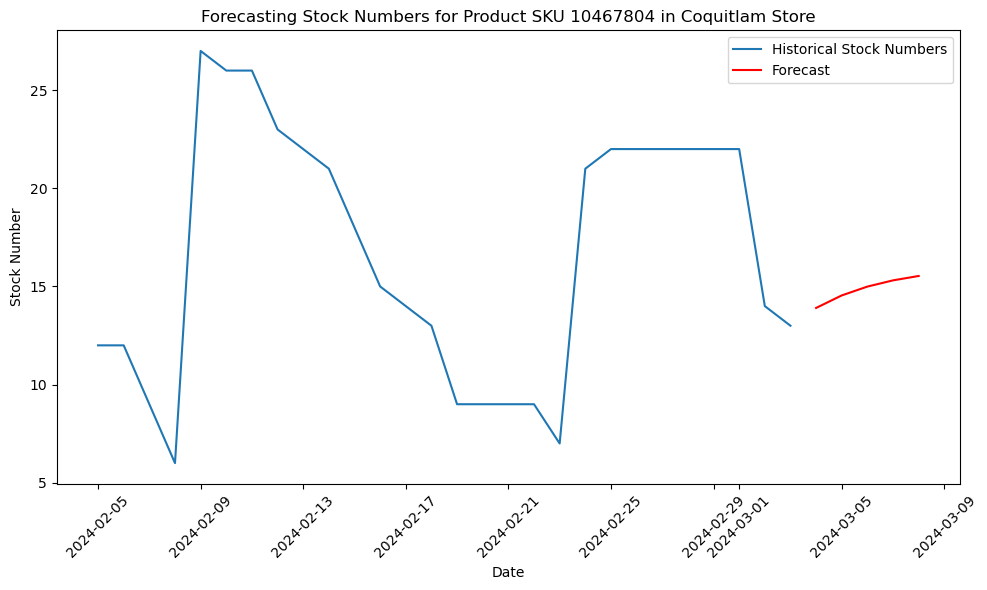

In [80]:
plt.figure(figsize=(10, 6))
plt.plot(stock_series.index, stock_series, label='Historical Stock Numbers')

# Corrected forecast_index generation without 'closed' argument
forecast_index = pd.date_range(start=stock_series.index[-1], periods=6)[1:]  # Start from the next day after the last observation

plt.plot(forecast_index, forecast, label='Forecast', color='red')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Stock Number')
plt.title('Forecasting Stock Numbers for Product SKU 10467804 in Coquitlam Store')
plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability
plt.tight_layout()  # Adjust layout
plt.show()



## Predict the stock demand, represented here as the change in stock levels at the Coquitlam store for a  product_sku 10467804 using linear regression

In [81]:
# Filter the DataFrame for the specific product_sku
specific_product = df[df['product_sku'] == 10467804]

# Ensure the data is sorted by date
specific_product_sorted = specific_product.sort_values(by='current_date')

# Calculate the stock level change
specific_product_sorted['stock_change_coquitlam'] = specific_product_sorted['stock_number_coquitlam'].diff()

# Since the first row for each SKU will have a NaN value for stock_change_coquitlam (no previous day to compare to), drop it
specific_product_sorted.dropna(subset=['stock_change_coquitlam'], inplace=True)

# Define features and target variable
X = specific_product_sorted[['stock_number_coquitlam']].iloc[:-1]  # Features: Previous day's stock levels
y = specific_product_sorted['stock_change_coquitlam'].iloc[1:]  # Target: Stock level change

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the testing set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Model Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"RMSE: {rmse}")

# Example: Predicting for a new stock level at Coquitlam
new_stock_level = 50  # Hypothetical stock level for a day
predicted_stock_change = model.predict([[new_stock_level]])
print(f"Predicted stock level change for a stock level of {new_stock_level}: {predicted_stock_change[0]:.2f} units")


Model Coefficients: [-0.38865937]
Intercept: 7.773807064656061
RMSE: 5.181613105919883
Predicted stock level change for a stock level of 50: -11.66 units


C:\Users\arifi\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


C:\Users\arifi\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


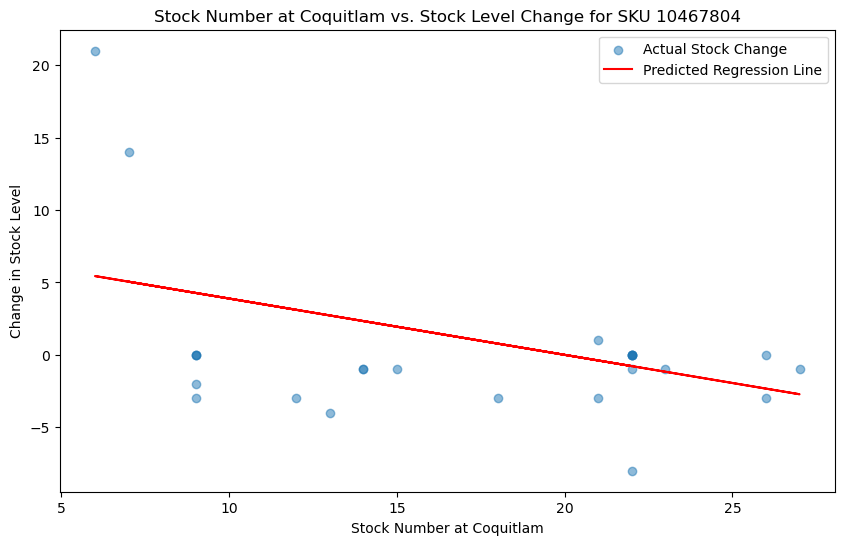

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for visualization
# Assuming `specific_product_sorted` is your filtered DataFrame for product_sku 10467804 with calculated 'stock_change_coquitlam'
X_vis = specific_product_sorted['stock_number_coquitlam'].iloc[:-1].values.reshape(-1, 1)  # Feature for visualization
y_vis = specific_product_sorted['stock_change_coquitlam'].iloc[1:].values  # Target for visualization

# Predict stock change for visualization
y_pred_vis = model.predict(X_vis)

# Scatter plot with regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_vis, y_vis, alpha=0.5, label='Actual Stock Change')
plt.plot(X_vis, y_pred_vis, color='red', label='Predicted Regression Line')
plt.title('Stock Number at Coquitlam vs. Stock Level Change for SKU 10467804')
plt.xlabel('Stock Number at Coquitlam')
plt.ylabel('Change in Stock Level')
plt.legend()
plt.show()



The negative trend suggests a potential predictive relationship where higher stock numbers could predict lower increases, or even decreases, in stock levels.

## 1.b Product Popularity in Coquitlam based on the time of it is being replenished

In [83]:
# Assuming df is structured with a 'product_sku', 'current_date', and multiple 'stock_number_*' columns
# First, ensure 'current_date' is in datetime format and sorted
#df['current_date'] = pd.to_datetime(df['current_date'])
df_popular = df.copy()

df_popular.sort_values(by='current_date', inplace=True)

# Select the column for stock change calculations
stock_column = 'stock_number_coquitlam'  # Example stock column for one store

# Calculate the difference in stock level from one record to the next for each product
df_popular['stock_change'] = df_popular.groupby('product_sku')[stock_column].diff()

# A positive stock change indicates a restocking event
df_popular['is_restocked'] = df_popular['stock_change'] > 0

# Count restocking events for each product
restock_counts = df_popular.groupby('product_sku')['is_restocked'].sum().reset_index()

# Merge to get product names and sizes without changing the original df
restock_counts_with_names = restock_counts.merge(
    df_popular[['product_sku', 'product_name', 'product_size']].drop_duplicates(), 
    on='product_sku', 
    how='left'
)

# Sort products by restocking frequency in descending order
restock_counts_sorted = restock_counts_with_names.sort_values(by='is_restocked', ascending=False)

# Select the top 10 products based on restocking frequency
top_10_replenished_products = restock_counts_sorted.head(10)[['product_sku', 'product_name', 'product_size', 'is_restocked']]

top_10_replenished_products

,product_sku,product_name,product_size,is_restocked
11,571679,"FEJKA, Artificial potted plant","12 cm (4 ¾ "")",10
97,90571670,"FEJKA, Artifi potted plant w pot, set of 3","6 cm (2 ¼ "")",9
61,50571672,"FEJKA, Artificial potted plant","15 cm (6 "")",9
62,50571691,"FEJKA, Artificial potted plant","12 cm (4 ¾ "")",8
5,409739,"SMYCKA, Artificial flower","130 cm (51 ¼ "")",7
76,70466811,"FEJKA, Artificial potted plant","9 cm (3 ½ "")",7
35,30433945,"FEJKA, Artificial potted plant","9 cm (3 ½ "")",7
91,80571675,"FEJKA, Artificial potted plant","9 cm (3 ½ "")",7
43,30571687,"FEJKA, Artificial potted plant","12 cm (4 ¾ "")",6
53,40571677,"FEJKA, Artificial potted plant","9 cm (3 ½ "")",6


## 2. Stock Numbers Impact on Price Drop Analysis

In [84]:
df['product_price_old'] = pd.to_numeric(df['product_price_old'].astype(str).str.replace('$', ''), errors='coerce')
df['product_price_new'] = pd.to_numeric(df['product_price_new'].astype(str).str.replace('$', ''), errors='coerce')

df_analysis = df.copy()

# Convert prices to numeric, assuming the price columns contain strings like '$10.00'
df_analysis['product_price_old'] = df_analysis['product_price_old'].replace('[\$,]', '', regex=True).astype(float)
df_analysis['product_price_new'] = pd.to_numeric(df_analysis['product_price_new'].replace('[\$,]', '', regex=True), errors='coerce')

# Drop rows where new price is NaN or old price is lower than or equal to the new price
df_discounted = df_analysis.dropna(subset=['product_price_new'])
df_discounted = df_discounted[df_discounted['product_price_old'] > df_discounted['product_price_new']]

# Create a binary feature for the presence of discount in the analysis DataFrame
df_analysis['discount_presence'] = df_analysis['product_sku'].isin(df_discounted['product_sku']).astype(int)

# Identify all stock number columns for each store
stock_columns = [col for col in df_analysis.columns if 'stock_number_' in col]

# Initialize a dictionary to store t-test and regression results
t_test_results = {}
regression_results = {}

# Loop through each store stock column to calculate changes, perform t-tests and regressions
for column in stock_columns:
    stock_change_col = f'stock_change_{column.split("_")[-1]}'
    df_analysis[stock_change_col] = df_analysis.groupby('product_sku')[column].diff()

    # Isolate discounted and non-discounted changes
    discounted_changes = df_analysis[df_analysis['discount_presence'] == 1][stock_change_col].dropna()
    non_discounted_changes = df_analysis[df_analysis['discount_presence'] == 0][stock_change_col].dropna()

    # Ensure there are enough samples for both discounted and non-discounted groups before performing t-test
    if len(discounted_changes) > 0 and len(non_discounted_changes) > 0:
        t_stat, p_value = stats.ttest_ind(discounted_changes, non_discounted_changes, equal_var=False, nan_policy='omit')
        t_test_results[column] = (t_stat, p_value)
    else:
        t_test_results[column] = (np.nan, np.nan)  # Indicates insufficient data for t-test

    # Prepare data for regression
    if len(df_analysis) > 0:
        X = df_analysis[['discount_presence']].loc[discounted_changes.index.union(non_discounted_changes.index)]
        y = df_analysis[stock_change_col].dropna().loc[X.index]

        # Check if X and y are non-empty and aligned
        if not X.empty and not y.empty and len(X) == len(y):
            model = LinearRegression()
            model.fit(X, y)
            regression_results[column] = (model.coef_, model.intercept_)
        else:
            regression_results[column] = (np.nan, np.nan)  # Indicates insufficient data for regression
    else:
        regression_results[column] = (np.nan, np.nan)  # Indicates no data available

# Output the results
for store, (t_stat, p_value) in t_test_results.items():
    print(f"{store} T-test: T-statistic = {t_stat}, P-value = {p_value}")

for store, (coefficients, intercept) in regression_results.items():
    if not np.isnan(coefficients):
        print(f"{store} Regression: Coefficients = {coefficients}, Intercept = {intercept}")
    else:
        print(f"{store} Regression: Insufficient data for regression analysis")

stock_number_coquitlam T-test: T-statistic = -2.2778350329417725, P-value = 0.02672505927907925
stock_number_richmond T-test: T-statistic = 0.514119270962631, P-value = 0.6092991601754758
stock_number_halifax T-test: T-statistic = 1.4397954023134845, P-value = 0.15577904066710746
stock_number_quebec T-test: T-statistic = -0.3909008124276371, P-value = 0.6974102690421745
stock_number_boucherville T-test: T-statistic = 1.4383250937692662, P-value = 0.15621549923506559
stock_number_montreal T-test: T-statistic = -0.4918854643537889, P-value = 0.6248244202180119
stock_number_ottawa T-test: T-statistic = -0.21855437271850178, P-value = 0.8278246893692007
stock_number_nyork T-test: T-statistic = 0.017046309985895333, P-value = 0.9864632097521486
stock_number_etobicoke T-test: T-statistic = 1.1342652950924472, P-value = 0.26173813710400473
stock_number_vaughan T-test: T-statistic = 0.7064369781888816, P-value = 0.4830052168988488
stock_number_burlington T-test: T-statistic = 0.769645109189061

### Coquitlam
T-test: T-statistic is -2.2778350329417725, and the P-value is 0.02672505927907925. This indicates a statistically significant decrease in stock levels when discounts are applied, as the P-value is less than 0.05.
Regression: The coefficient is -14.20178878, and the intercept is -0.335248256052524. This suggests that applying a discount is associated with an average decrease in stock levels by approximately 14.2 units in Coquitlam.
### Ottawa
T-test: T-statistic is -0.21855437271850178, and the P-value is 0.8278246893692007. The difference in stock level changes between discounted and non-discounted items is not statistically significant, given the P-value is much greater than 0.05.
Regression: The coefficient is -1.14098998, and the intercept is -0.22938038572014782. Despite the negative coefficient, which would suggest a decrease in stock levels with discounts, the lack of statistical significance from the T-test suggests we cannot confidently say that discounts lead to stock reductions in Ottawa.
### Alberta (AB)
T-test: T-statistic is -0.4036034952263552, and the P-value is 0.6881014939371589. This result is not statistically significant, as the P-value is well above 0.05.
Regression: The coefficient is -2.96775027, and the intercept is -0.661879359868691. Though the negative coefficient implies that discounts might be associated with a decrease in stock levels, the T-test result indicates that this finding is not statistically significant for Alberta.
### Quebec (QC)
T-test: T-statistic is 0.7045582961292991, and the P-value is 0.4841623756064044. There is no statistically significant difference in stock levels between discounted and non-discounted items since the P-value is greater than 0.05.
Regression: The coefficient is 16.17725953, and the intercept is -0.7513336068937212. The positive coefficient indicates an association between discounts and an increase in stock levels. However, the non-significant P-value from the T-test suggests that this relationship may not be reliable and could be due to random variation.

For each of these provinces, the T-test determines if the difference in means (average stock change between discounted and non-discounted items) is statistically significant. The regression analysis provides an estimate of the relationship's magnitude between the discount presence and the stock change. A statistically significant P-value in the T-test would give us confidence that the observed differences or trends are not just due to random chance, while the regression coefficient gives the direction and size of the relationship. In the cases of Ottawa, Alberta, and Quebec, the high P-values suggest that the observed effects of discounts on stock changes are not statistically significant. Conversely, for Coquitlam, the results indicate a significant relationship between discounts and stock changes.

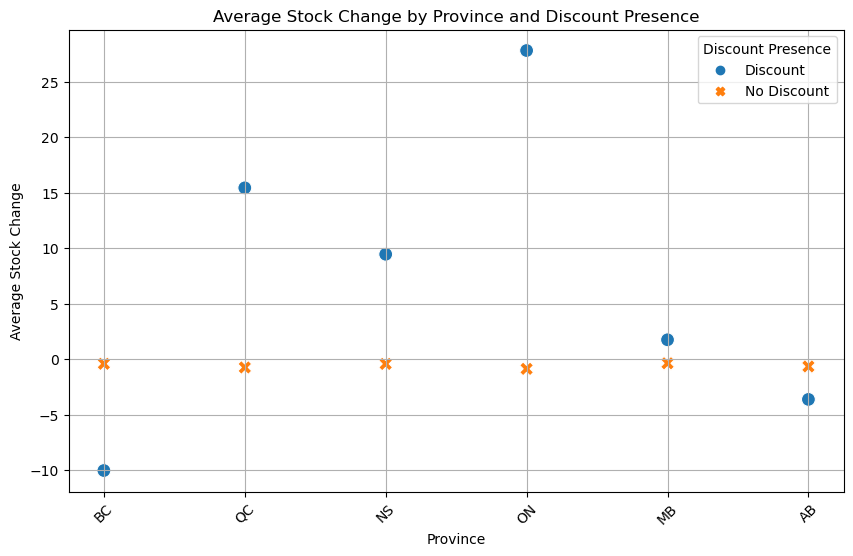

In [85]:
provinces = ['BC', 'QC', 'NS', 'ON', 'MB', 'AB']

# Initialize a dictionary to hold average stock change values for discount presence (1) and absence (0)
avg_stock_change = {province: {'discount': None, 'no_discount': None} for province in provinces}

# Calculate the average stock change for each province, for discounted (1) and non-discounted (0) separately
for province in provinces:
    stock_change_col = f'stock_change_{province}'
    # Calculate averages
    avg_stock_change[province]['discount'] = df_analysis[df_analysis['discount_presence'] == 1][stock_change_col].mean()
    avg_stock_change[province]['no_discount'] = df_analysis[df_analysis['discount_presence'] == 0][stock_change_col].mean()

# Convert the averages to a DataFrame for easier plotting
avg_df = pd.DataFrame(avg_stock_change).T.reset_index()
avg_df.rename(columns={'index': 'Province', 'discount': 'Discount', 'no_discount': 'No Discount'}, inplace=True)
avg_df_melted = avg_df.melt(id_vars='Province', var_name='Discount Presence', value_name='Average Stock Change')

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=avg_df_melted, x='Province', y='Average Stock Change', hue='Discount Presence', style='Discount Presence', s=100)

plt.title('Average Stock Change by Province and Discount Presence')
plt.xticks(rotation=45)  # Rotate province names for better readability
plt.grid(True)

plt.show()

- Variability in Discount Impact: The difference in position between blue and orange markers varies by province, suggesting that the impact of discounts on stock changes is not uniform across all provinces.
- BC and AB: For these provinces, discounted products (blue circles) are associated with a significant decrease in stock levels compared to non-discounted products (orange X's). This might suggest higher sales or stock movements when discounts are applied, leading to stock depletion.
- QC, NS, ON, MB: In these provinces, discounted products do not show a large difference in stock change compared to non-discounted products. For QC and NS, there is virtually no difference, while for ON and MB, there's a slight decrease for discounted stock, but it's not as pronounced as in BC and AB.
- Negative Stock Changes: Most provinces show a decrease in stock for discounted items, except for NS, where the average stock change is slightly positive regardless of discount presence.

In [86]:
# # Calculate the discount rate where applicable
# df['discount_rate'] = ((df['product_price_old'] - df['product_price_new']) / df['product_price_old']) * 100

# # Flag products with a discount
# df['has_discount'] = df['discount_rate'] > 0
# # Sort by SKU and date to correctly calculate stock changes
# df.sort_values(by=['product_sku', 'current_date'], inplace=True)

# # Calculate stock changes for each location; example for Coquitlam
# df['stock_change_coquitlam'] = df.groupby('product_sku')['stock_number_coquitlam'].diff()

# # Flag days with stock replenishment for Coquitlam
# df['is_replenished_coquitlam'] = df['stock_change_coquitlam'] > 0
# # Calculate average replenishment rates for products with and without discounts in Coquitlam
# avg_replenish_rate_with_discount = df[df['has_discount']]['is_replenished_coquitlam'].mean()
# avg_replenish_rate_without_discount = df[~df['has_discount']]['is_replenished_coquitlam'].mean()

# print(f"Average Replenishment Rate with Discount: {avg_replenish_rate_with_discount}")
# print(f"Average Replenishment Rate without Discount: {avg_replenish_rate_without_discount}")

# from scipy.stats import ttest_ind

# # Separate the replenishment indicators
# replenished_with_discount = df[df['has_discount']]['is_replenished_coquitlam']
# replenished_without_discount = df[~df['has_discount']]['is_replenished_coquitlam']

# # Perform a t-test
# t_stat, p_value = ttest_ind(replenished_with_discount.dropna(), replenished_without_discount.dropna(), equal_var=False)

# print(f"T-Statistic: {t_stat}, P-Value: {p_value}")


<!-- ### Interpretation of the Results:
Average Replenishment Rate with Discount (0.2314): On average, about 23.14% of the time, products with a discount are replenished. This suggests that for products that have been discounted, there's a replenishment (stock increase) on approximately 1 out of every 4 days observed.

Average Replenishment Rate without Discount (0.1746): For products without a discount, the average replenishment rate is about 17.46%. This indicates that non-discounted products are replenished on roughly 1 out of every 6 days observed.

Higher Replenishment for Discounted Items: Products with discounts tend to have a higher rate of replenishment compared to those without discounts. This could be indicative of either higher sales velocity due to the attractiveness of discounts, leading to more frequent restocking, or a strategic focus on ensuring discounted items are adequately stocked. -->

Model Coefficients: The coefficient of -0.3887 for the stock level indicates that for every additional unit increase in the stock number at Coquitlam, the change in stock level (which we're using as a proxy for demand) decreases by about 0.389 units. This negative relationship suggests that higher initial stock levels might lead to a smaller change (potentially less restocking needed), which could imply lower demand or slower sales for higher initial stock levels.

Intercept: The intercept of 7.774 means that if the stock number at Coquitlam starts at zero , the expected change in stock level is approximately +7.774 units.

RMSE: The Root Mean Squared Error of 5.182 suggests the standard deviation of the prediction errors is about 5.182 units. 

### 3. Product Segmentation Analysis

In [87]:
bucket_name = 'csis4495'
folder_name = 'weekly_real_plants'
file_pattern = 'weekly_products_real_plants_'

# Initialize s3fs filesystem object
fs = s3fs.S3FileSystem(anon=False)  # Use anon=False if your S3 bucket is private

# List all files in the specified folder
path = f'{bucket_name}/{folder_name}'  # Adjusted to include the folder name
files = fs.ls(path)

# Filter files by your pattern
csv_files = [f for f in files if file_pattern in f]

# Read and concatenate all matching CSV files into a single DataFrame
df_list = []
for file in csv_files:
    with fs.open(f'{file}') as f:
        df_list.append(pd.read_csv(f, encoding='ISO-8859-1'))

df2 = pd.concat(df_list, ignore_index=True)



# Add a new column with 'artificial' as its value for every row
df2['product_type'] = 'real'

# Summing stock numbers for British Columbia (BC)
df2['stock_number_BC'] = df2['stock_number_coquitlam'] + df2['stock_number_richmond']

# Summing stock numbers for Quebec (QC)
df2['stock_number_QC'] = df2['stock_number_quebec'] + df2['stock_number_boucherville'] + df2['stock_number_montreal']

# Stock number for Nova Scotia (NS) is just from Halifax
df2['stock_number_NS'] = df2['stock_number_halifax']

# Summing stock numbers for Ontario (ON)
df2['stock_number_ON'] = df2['stock_number_ottawa'] + df2['stock_number_nyork'] + df2['stock_number_etobicoke'] + df2['stock_number_vaughan'] + df2['stock_number_burlington'] +  df2['stock_number_burlington'] 

# Stock number for Manitoba (MB) is just from Winnipeg
df2['stock_number_MB'] = df2['stock_number_winnipeg']

# Summing stock numbers for Alberta (AB)
df2['stock_number_AB'] = df2['stock_number_edmonton'] + df2['stock_number_calgary']

# Display the shape and first few rows of the concatenated DataFrame
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4398 entries, 0 to 4397
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   current_date                    4398 non-null   object
 1   image_url                       4398 non-null   object
 2   product_name                    4398 non-null   object
 3   product_link                    4398 non-null   object
 4   product_size                    4170 non-null   object
 5   product_sku                     4398 non-null   int64 
 6   product_price_old               4398 non-null   object
 7   product_price_new               56 non-null     object
 8   stock_probability_coquitlam     4358 non-null   object
 9   stock_number_coquitlam          4398 non-null   int64 
 10  stock_probability_richmond      4333 non-null   object
 11  stock_number_richmond           4398 non-null   int64 
 12  stock_probability_halifax       4398 non-null   

In [88]:
df_real = df2[
    df2['product_name'].str.contains('potted plant', case=False) &
    ~df2['product_name'].str.contains('artificial', case=False)
]

# Display the shape and first few rows of the filtered DataFrame
df_real.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1209 entries, 0 to 4344
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   current_date                    1209 non-null   object
 1   image_url                       1209 non-null   object
 2   product_name                    1209 non-null   object
 3   product_link                    1209 non-null   object
 4   product_size                    1209 non-null   object
 5   product_sku                     1209 non-null   int64 
 6   product_price_old               1209 non-null   object
 7   product_price_new               0 non-null      object
 8   stock_probability_coquitlam     1199 non-null   object
 9   stock_number_coquitlam          1209 non-null   int64 
 10  stock_probability_richmond      1193 non-null   object
 11  stock_number_richmond           1209 non-null   int64 
 12  stock_probability_halifax       1209 non-null   objec

In [89]:
df_real.head(50)

,current_date,image_url,product_name,product_link,product_size,product_sku,product_price_old,product_price_new,stock_probability_coquitlam,stock_number_coquitlam,...,stock_number_edmonton,stock_probability_calgary,stock_number_calgary,product_type,stock_number_BC,stock_number_QC,stock_number_NS,stock_number_ON,stock_number_MB,stock_number_AB
0,2024/02/05,https://www.ikea.com/ca/en/images/products/him...,"HIMALAYAMIX, Potted plant",https://www.ikea.com/ca/en/p/himalayamix-potte...,"10 cm (4 "")",20197227,$4.99,NaN,OUT_OF_STOCK,0,...,12,MEDIUM_IN_STOCK,4,real,17,232,108,812,96,16
1,2024/02/05,https://www.ikea.com/ca/en/images/products/san...,"SANSEVIERIA TRIFASCIATA, Potted plant",https://www.ikea.com/ca/en/p/sansevieria-trifa...,"15 cm (6 "")",90296969,$9.99,NaN,HIGH_IN_STOCK,23,...,2,HIGH_IN_STOCK,50,real,24,84,36,152,28,52
2,2024/02/05,https://www.ikea.com/ca/en/images/products/tro...,"TROPISK, Potted plant",https://www.ikea.com/ca/en/p/tropisk-potted-pl...,"30.5 cm (12 "")",70219137,$64.99,NaN,HIGH_IN_STOCK,15,...,2,HIGH_IN_STOCK,50,real,22,13,3,147,28,52
3,2024/02/05,https://www.ikea.com/ca/en/images/products/dra...,"DRACAENA MARGINATA, Potted plant",https://www.ikea.com/ca/en/p/dracaena-marginat...,"20.5 cm (8 "")",80303531,$22.99,NaN,HIGH_IN_STOCK,34,...,33,HIGH_IN_STOCK,22,real,39,94,14,92,23,55
4,2024/02/05,https://www.ikea.com/ca/en/images/products/pac...,"PACHIRA AQUATICA, Potted plant",https://www.ikea.com/ca/en/p/pachira-aquatica-...,"13 cm (5 "")",40399173,$12.99,NaN,HIGH_IN_STOCK,19,...,58,HIGH_IN_STOCK,43,real,34,97,20,102,40,101
5,2024/02/05,https://www.ikea.com/ca/en/images/products/zam...,"ZAMIOCULCAS, Potted plant",https://www.ikea.com/ca/en/p/zamioculcas-potte...,"15 cm (6 "")",10069107,$16.99,NaN,HIGH_IN_STOCK,48,...,0,HIGH_IN_STOCK,28,real,79,0,0,0,18,28
6,2024/02/05,https://www.ikea.com/ca/en/images/products/pal...,"PALMMIX, Potted plant",https://www.ikea.com/ca/en/p/palmmix-potted-pl...,"24 cm (9 ½ "")",80493673,$24.99,NaN,HIGH_IN_STOCK,20,...,2,MEDIUM_IN_STOCK,2,real,29,41,16,49,13,4
7,2024/02/05,https://www.ikea.com/ca/en/images/products/mon...,"MONSTERA DELICIOSA, Potted plant",https://www.ikea.com/ca/en/p/monstera-delicios...,"24 cm (9 ½ "")",70555973,$39.99,NaN,OUT_OF_STOCK,0,...,0,OUT_OF_STOCK,0,real,7,10,3,18,0,0
8,2024/02/05,https://www.ikea.com/ca/en/images/products/fic...,"FICUS LYRATA, Potted plant",https://www.ikea.com/ca/en/p/ficus-lyrata-pott...,"24 cm (9 ½ "")",90399175,$29.99,NaN,OUT_OF_STOCK,0,...,0,OUT_OF_STOCK,0,real,0,43,16,31,6,0
9,2024/02/05,https://www.ikea.com/ca/en/images/products/epi...,"EPIPREMNUM, Potted plant",https://www.ikea.com/ca/en/p/epipremnum-potted...,"15 cm (6 "")",80305361,$9.99,NaN,HIGH_IN_STOCK,43,...,0,OUT_OF_STOCK,0,real,109,170,36,33,6,0


In [90]:
df_combined = pd.concat([df, df_real], ignore_index=True)
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3802 entries, 0 to 3801
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   current_date                    3802 non-null   object 
 1   image_url                       3802 non-null   object 
 2   product_name                    3802 non-null   object 
 3   product_link                    3802 non-null   object 
 4   product_size                    3679 non-null   object 
 5   product_sku                     3802 non-null   int64  
 6   product_price_old               3802 non-null   object 
 7   product_price_new               56 non-null     float64
 8   stock_probability_coquitlam     3792 non-null   object 
 9   stock_number_coquitlam          3802 non-null   int64  
 10  stock_probability_richmond      3786 non-null   object 
 11  stock_number_richmond           3802 non-null   int64  
 12  stock_probability_halifax       38

In [91]:
# Assuming df_combined is your combined DataFrame
duplicate_rows = df_combined.duplicated()

# To see if there are any duplicate rows
has_duplicates = duplicate_rows.any()
print("Are there any duplicate rows?", has_duplicates)

# To count the number of duplicate rows
number_of_duplicates = duplicate_rows.sum()
print("Number of duplicate rows:", number_of_duplicates)


Are there any duplicate rows? True
Number of duplicate rows: 43


In [92]:
# To view the duplicate rows
duplicate_rows_df = df_combined[duplicate_rows]
print(duplicate_rows_df)

     current_date                                          image_url  \
2636   2024/02/05  https://www.ikea.com/ca/en/images/products/him...   
2637   2024/02/05  https://www.ikea.com/ca/en/images/products/san...   
2638   2024/02/05  https://www.ikea.com/ca/en/images/products/tro...   
2639   2024/02/05  https://www.ikea.com/ca/en/images/products/dra...   
2640   2024/02/05  https://www.ikea.com/ca/en/images/products/pac...   
2641   2024/02/05  https://www.ikea.com/ca/en/images/products/zam...   
2642   2024/02/05  https://www.ikea.com/ca/en/images/products/pal...   
2643   2024/02/05  https://www.ikea.com/ca/en/images/products/mon...   
2644   2024/02/05  https://www.ikea.com/ca/en/images/products/fic...   
2645   2024/02/05  https://www.ikea.com/ca/en/images/products/epi...   
2646   2024/02/05  https://www.ikea.com/ca/en/images/products/cha...   
2647   2024/02/05  https://www.ikea.com/ca/en/images/products/san...   
2648   2024/02/05  https://www.ikea.com/ca/en/images/products/pa

[43 rows x 45 columns]


In [93]:
# Assuming df_combined is your combined DataFrame
# Remove duplicate rows and keep the first occurrence of each duplicate
df_combined = df_combined.drop_duplicates()

# If you want to keep the last occurrence of each duplicate instead
df_combined = df_combined.drop_duplicates(keep='last')

duplicate_rows = df_combined.duplicated()

has_duplicates = duplicate_rows.any()
print("Are there any duplicate rows?", has_duplicates)

# To count the number of duplicate rows
number_of_duplicates = duplicate_rows.sum()
print("Number of duplicate rows:", number_of_duplicates)


Are there any duplicate rows? False
Number of duplicate rows: 0


In [94]:
# Convert 'product_type' to numerical format using One-Hot Encoding
df_encoded = pd.get_dummies(df_combined, columns=['product_type'])

In [97]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Assuming df_combined is your DataFrame after combining artificial and real plants

# Select numerical features for clustering (excluding non-numerical or irrelevant columns)
features = df_combined.select_dtypes(include=[np.number])

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Impute missing values (if any)
imputer = SimpleImputer(strategy='mean')
features_imputed = imputer.fit_transform(features_scaled)

# Perform K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # adjust n_clusters based on your analysis
clusters = kmeans.fit_predict(features_imputed)

# Add the cluster labels to your DataFrame
df_combined['cluster'] = clusters


C:\Users\arifi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


AttributeError: 'NoneType' object has no attribute 'split'